In [1]:
# ============================================================
# FASE 3: IL MODELLO (LightGBM)
# File: 02_model_training.ipynb
# ============================================================

import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import joblib
import os

# ============================================================
# CELLA 1: RICREAZIONE DEL DATASET
# (Perché la Fase 2 potrebbe non aver salvato il CSV)
# ============================================================

# Proviamo a caricare il file salvato dalla Fase 2
percorso_dati = 'data/processed/dati_modello.csv'

if os.path.exists(percorso_dati):
    print("✅ File trovato! Caricamento in corso...")
    df = pd.read_csv(percorso_dati)
else:
    print("⚠️ File non trovato. Ricreo il dataset dalla sorgente...")
    
    train = pd.read_csv('data/raw/train.csv')
    meal_info = pd.read_csv('data/raw/meal_info.csv')
    center_info = pd.read_csv('data/raw/fulfilment_center_info.csv')

    df = train.merge(meal_info, on='meal_id', how='left')
    df = df.merge(center_info, on='center_id', how='left')

    # Capping outlier al 99° percentile
    limite_superiore = df['num_orders'].quantile(0.99)
    df['num_orders_capped'] = np.where(
        df['num_orders'] > limite_superiore, limite_superiore, df['num_orders']
    )
    df['log_num_orders'] = np.log1p(df['num_orders_capped'])

    # Macro-categorie (simulazione Agente LLM)
    mappa_macro = {
        'Beverages': 'Bevande_e_Extra', 'Extras': 'Bevande_e_Extra',
        'Soup': 'Pasti_Leggeri', 'Salad': 'Pasti_Leggeri', 'Starters': 'Pasti_Leggeri',
        'Other Snacks': 'Snack_e_Dolci', 'Desert': 'Snack_e_Dolci',
        'Pizza': 'Fast_Food', 'Pasta': 'Fast_Food', 'Sandwich': 'Fast_Food',
        'Rice Bowl': 'Piatti_Principali', 'Biryani': 'Piatti_Principali',
        'Fish': 'Piatti_Principali', 'Seafood': 'Piatti_Principali'
    }
    df['Macro_Categoria'] = df['category'].map(mappa_macro)

    # Ordina per serie temporale
    df = df.sort_values(by=['center_id', 'meal_id', 'week']).reset_index(drop=True)

    # Lag features (shift = 1 settimana indietro)
    df['lag_1w'] = df.groupby(['center_id', 'meal_id'])['num_orders_capped'].shift(1)
    df['lag_1w_log'] = df.groupby(['center_id', 'meal_id'])['log_num_orders'].shift(1)
    
    # Media mobile a 4 settimane (un mese di storico)
    df['Media_Mobile_4w'] = df.groupby(['center_id', 'meal_id'])['num_orders_capped'].transform(
        lambda x: x.shift(1).rolling(window=4, min_periods=1).mean()
    )

    # Sconto
    df['Sconto_Valore'] = df['base_price'] - df['checkout_price']
    df['Sconto_Percentuale'] = np.where(
        df['base_price'] > 0, df['Sconto_Valore'] / df['base_price'], 0
    )

    # Rimuovi righe senza storico (la prima settimana di ogni serie)
    df = df.dropna(subset=['Ordini_Settimana_Scorsa']).copy()
    
    # Salva per le fasi successive
    os.makedirs('data/processed', exist_ok=True)
    df.to_csv(percorso_dati, index=False)
    print(f"✅ Dataset salvato in '{percorso_dati}'")

print(f"\nDimensioni dataset: {df.shape}")
print(f"Settimane: da {df['week'].min()} a {df['week'].max()} ({df['week'].nunique()} settimane)")

✅ File trovato! Caricamento in corso...

Dimensioni dataset: (452951, 32)
Settimane: da 2 a 145 (144 settimane)


In [3]:
# ============================================================
# CELLA 2: PREPARAZIONE FEATURES E VARIABILI CATEGORICHE
# ============================================================

# Convertiamo le colonne categoriche nel tipo giusto per LightGBM
colonne_categoriche = ['category', 'cuisine', 'center_type', 'Macro_Categoria',
                       'city_code', 'region_code', 'center_id', 'meal_id', 'trimestre']

for col in colonne_categoriche:
    df[col] = df[col].astype('category')

# Lista completa delle features che il modello userà
features = [
    # Identificatori (come categoriche)
    'center_id', 'meal_id',
    
    # Prezzi e promozioni
    'checkout_price', 'base_price', 'Sconto_Valore', 'Sconto_Percentuale',
    'emailer_for_promotion', 'homepage_featured',
    
    # Caratteristiche strutturali
    'category', 'cuisine', 'center_type', 'op_area', 'Macro_Categoria',
    'city_code', 'region_code',
    
    # Lag features (NUOVO: prima c'era solo lag-1, ora anche lag-2 e lag-4)
    'lag_1w', 'lag_1w_log',
    'lag_2w', 'lag_2w_log',          # ← AGGIUNTO
    'lag_4w', 'lag_4w_log',          # ← AGGIUNTO
    
    # Medie mobili e volatilità (NUOVO: non esistevano prima)
    'media_mobile_4w',               # ← AGGIUNTO
    'media_mobile_8w',               # ← AGGIUNTO
    'std_mobile_4w',                 # ← AGGIUNTO
    
    # Tempo e calendario (NUOVO: prima c'era solo 'week')
    'week',
    'mese_approx',                   # ← AGGIUNTO
    'settimana_anno',                # ← AGGIUNTO
    'trimestre'                      # ← AGGIUNTO
]

# Verifica che tutte le features esistano nel dataset
features_mancanti = [f for f in features if f not in df.columns]
if features_mancanti:
    print(f"⚠️ Features mancanti: {features_mancanti}")
    features = [f for f in features if f in df.columns]

print(f"✅ {len(features)} features selezionate:")
for i, f in enumerate(features, 1):
    tipo = 'CAT' if f in colonne_categoriche else 'NUM'
    print(f"   {i:2d}. {f:<35s} [{tipo}]")

✅ 28 features selezionate:
    1. center_id                           [CAT]
    2. meal_id                             [CAT]
    3. checkout_price                      [NUM]
    4. base_price                          [NUM]
    5. Sconto_Valore                       [NUM]
    6. Sconto_Percentuale                  [NUM]
    7. emailer_for_promotion               [NUM]
    8. homepage_featured                   [NUM]
    9. category                            [CAT]
   10. cuisine                             [CAT]
   11. center_type                         [CAT]
   12. op_area                             [NUM]
   13. Macro_Categoria                     [CAT]
   14. city_code                           [CAT]
   15. region_code                         [CAT]
   16. lag_1w                              [NUM]
   17. lag_1w_log                          [NUM]
   18. lag_2w                              [NUM]
   19. lag_2w_log                          [NUM]
   20. lag_4w                             

In [4]:
# ============================================================
# CELLA 3: SPLIT TEMPORALE (Train / Validation / Test)
# ============================================================
# 
# Settimane disponibili: 2 → 145  (144 settimane)
#
# ┌────────────────────────┬──────────┬──────────┐
# │      TRAIN             │   VAL    │   TEST   │
# │  week 2 → 133          │ 134→141  │ 142→145  │
# │  (~132 settimane)      │(~8 sett) │(~4 sett) │
# └────────────────────────┴──────────┴──────────┘
#
# - TRAIN: il modello studia questi dati
# - VALIDATION: il modello usa questi per capire quando fermarsi (early stopping)
# - TEST: il "futuro" simulato — MAI visto dal modello, neanche indirettamente

SETTIMANA_VAL = 134   # Inizio validation
SETTIMANA_TEST = 142  # Inizio test (ultimo "mese")

df_train = df[df['week'] < SETTIMANA_VAL].copy()
df_val   = df[(df['week'] >= SETTIMANA_VAL) & (df['week'] < SETTIMANA_TEST)].copy()
df_test  = df[df['week'] >= SETTIMANA_TEST].copy()

X_train = df_train[features]
y_train = df_train['log_num_orders']

X_val = df_val[features]
y_val = df_val['log_num_orders']

X_test = df_test[features]
y_test_log = df_test['log_num_orders']
y_test_reale = df_test['num_orders_capped']  # Ordini reali per il confronto finale

print(f"TRAIN:      {X_train.shape[0]:>7,} righe  (settimane {df_train['week'].min()}–{df_train['week'].max()})")
print(f"VALIDATION: {X_val.shape[0]:>7,} righe  (settimane {df_val['week'].min()}–{df_val['week'].max()})")
print(f"TEST:       {X_test.shape[0]:>7,} righe  (settimane {df_test['week'].min()}–{df_test['week'].max()})")

TRAIN:      413,541 righe  (settimane 2–133)
VALIDATION:  26,297 righe  (settimane 134–141)
TEST:        13,113 righe  (settimane 142–145)


In [6]:
# ============================================================
# CELLA 4: LA BASELINE (Il "cattivo" da sconfiggere)
# ============================================================
# Regola stupida: "La prossima settimana venderò esattamente 
# quello che ho venduto la settimana scorsa" (Seasonal Naive)

# Gestione NaN: se per qualche serie non abbiamo lo storico,
# usiamo la mediana globale come fallback
mediana_globale = df_train['num_orders_capped'].median()
baseline_pred = df_test['lag_1w'].fillna(mediana_globale)

# Calcoliamo MAE e RMSE della baseline
mae_baseline = mean_absolute_error(y_test_reale, baseline_pred)
rmse_baseline = np.sqrt(mean_squared_error(y_test_reale, baseline_pred))

print("=" * 55)
print("       📊 BASELINE: 'Ordini = Settimana Scorsa'")
print("=" * 55)
print(f"  MAE  (errore medio):      {mae_baseline:>10.2f} ordini")
print(f"  RMSE (errore quadratico): {rmse_baseline:>10.2f} ordini")
print(f"  Media ordini reali test:  {y_test_reale.mean():>10.2f} ordini")
print("=" * 55)

       📊 BASELINE: 'Ordini = Settimana Scorsa'
  MAE  (errore medio):           76.15 ordini
  RMSE (errore quadratico):     129.63 ordini
  Media ordini reali test:      225.39 ordini


In [7]:
# ============================================================
# CELLA 5: ADDESTRAMENTO LightGBM CON EARLY STOPPING
# ============================================================

print("🚀 Addestramento LightGBM in corso...\n")

modello_lgb = lgb.LGBMRegressor(
    n_estimators=1000,       # Tetto massimo di alberi (l'early stopping lo fermerà prima)
    learning_rate=0.05,      # Velocità di apprendimento
    num_leaves=31,           # Complessità di ogni albero
    max_depth=-1,            # Nessun limite di profondità
    min_child_samples=20,    # Minimo di campioni per foglia (anti-overfitting)
    subsample=0.8,           # Usa l'80% dei dati per ogni albero (anti-overfitting)
    colsample_bytree=0.8,   # Usa l'80% delle features per ogni albero
    reg_alpha=0.1,           # Regolarizzazione L1
    reg_lambda=0.1,          # Regolarizzazione L2
    random_state=42,
    n_jobs=-1,               # Usa tutti i core del processore
    verbose=-1               # Silenzia i log durante il training
)

# Identifica i nomi delle colonne categoriche presenti nelle features
cat_features_in_model = [c for c in colonne_categoriche if c in features]

# Addestramento con Early Stopping
# Il modello si ferma se l'errore sul validation set non migliora per 50 alberi consecutivi
modello_lgb.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    eval_metric='mae',
    callbacks=[
        lgb.early_stopping(stopping_rounds=50, verbose=True),
        lgb.log_evaluation(period=100)  # Stampa log ogni 100 alberi
    ],
    categorical_feature=cat_features_in_model
)

print(f"\n✅ Modello addestrato con {modello_lgb.best_iteration_} alberi (su max 1000)")

🚀 Addestramento LightGBM in corso...

Training until validation scores don't improve for 50 rounds
[100]	valid_0's l1: 0.384916	valid_0's l2: 0.248571
Early stopping, best iteration is:
[145]	valid_0's l1: 0.383169	valid_0's l2: 0.246131

✅ Modello addestrato con 145 alberi (su max 1000)


In [8]:
# ============================================================
# CELLA 6: VALUTAZIONE SUL TEST SET
# ============================================================

# Il modello predice in scala logaritmica
previsioni_log = modello_lgb.predict(X_test)

# Torniamo alla scala originale e clippiamo a zero (non esistono ordini negativi!)
previsioni_reali = np.expm1(previsioni_log).clip(min=0)

# Metriche del modello
mae_lgb = mean_absolute_error(y_test_reale, previsioni_reali)
rmse_lgb = np.sqrt(mean_squared_error(y_test_reale, previsioni_reali))

# Miglioramento percentuale rispetto alla baseline
miglioramento_mae = ((mae_baseline - mae_lgb) / mae_baseline) * 100
miglioramento_rmse = ((rmse_baseline - rmse_lgb) / rmse_baseline) * 100

# Tabella riassuntiva
print("\n" + "=" * 65)
print("          📊 CONFRONTO FINALE: BASELINE vs LightGBM")
print("=" * 65)
print(f"{'Metrica':<30} {'Baseline':>12} {'LightGBM':>12} {'Δ%':>8}")
print("-" * 65)
print(f"{'MAE (ordini medi di errore)':<30} {mae_baseline:>12.2f} {mae_lgb:>12.2f} {miglioramento_mae:>+7.1f}%")
print(f"{'RMSE':<30} {rmse_baseline:>12.2f} {rmse_lgb:>12.2f} {miglioramento_rmse:>+7.1f}%")
print("=" * 65)

if mae_lgb < mae_baseline:
    print(f"\n✅ VITTORIA! Il modello LightGBM batte la baseline del {miglioramento_mae:.1f}%")
else:
    print(f"\n❌ ATTENZIONE: Il modello NON batte la baseline. Rivedere le features.")


          📊 CONFRONTO FINALE: BASELINE vs LightGBM
Metrica                            Baseline     LightGBM       Δ%
-----------------------------------------------------------------
MAE (ordini medi di errore)           76.15        60.47   +20.6%
RMSE                                 129.63       102.81   +20.7%

✅ VITTORIA! Il modello LightGBM batte la baseline del 20.6%


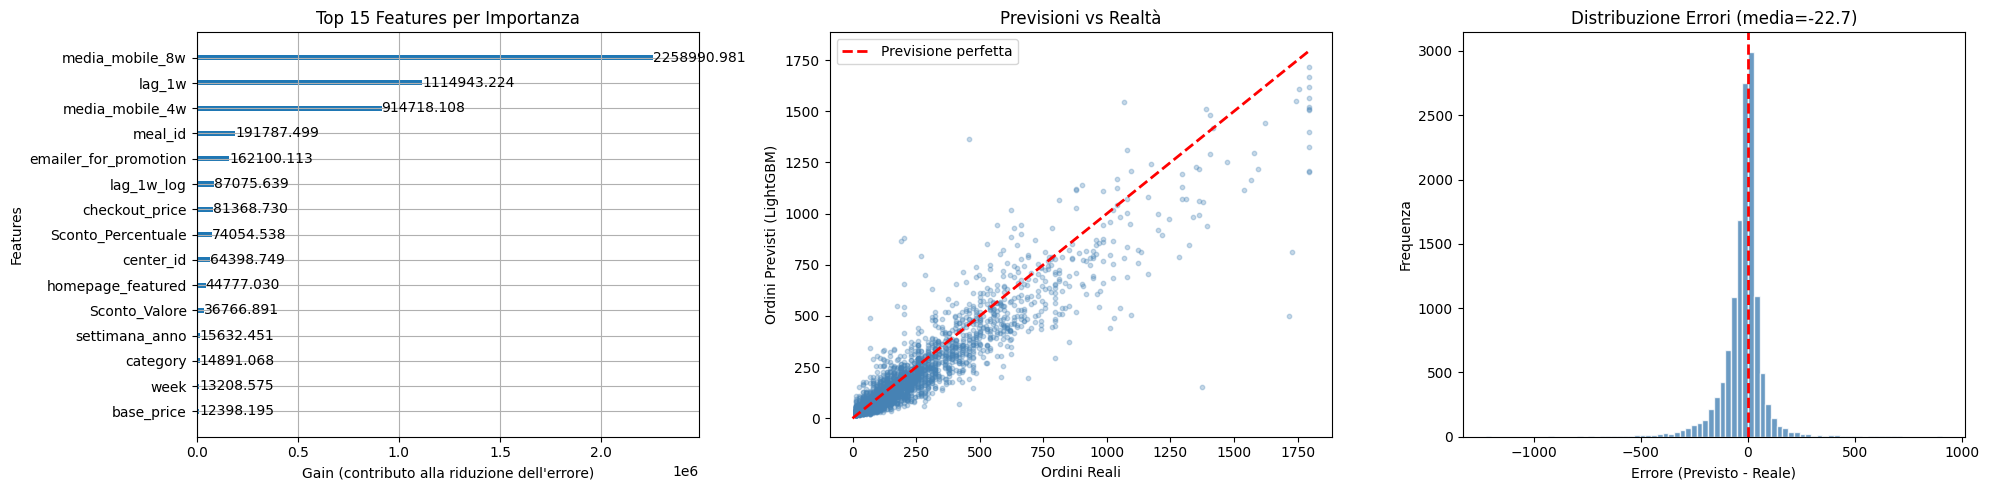

✅ Grafico salvato con successo in 'img/modello_valutazione.png'


In [9]:
# ============================================================
# CELLA 7: VISUALIZZAZIONI
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# --- Grafico 1: Importanza delle Features ---
lgb.plot_importance(
    modello_lgb, max_num_features=15, importance_type='gain',
    title="Top 15 Features per Importanza", ax=axes[0]
)
axes[0].set_xlabel("Gain (contributo alla riduzione dell'errore)")

# --- Grafico 2: Previsioni vs Reali (scatter) ---
# Campione casuale per non sovraccaricare il grafico
campione = min(3000, len(y_test_reale))
idx = np.random.RandomState(42).choice(len(y_test_reale), campione, replace=False)

axes[1].scatter(y_test_reale.values[idx], previsioni_reali[idx], alpha=0.3, s=10, color='steelblue')
max_val = max(y_test_reale.values[idx].max(), previsioni_reali[idx].max())
axes[1].plot([0, max_val], [0, max_val], 'r--', linewidth=2, label='Previsione perfetta')
axes[1].set_xlabel("Ordini Reali")
axes[1].set_ylabel("Ordini Previsti (LightGBM)")
axes[1].set_title("Previsioni vs Realtà")
axes[1].legend()

# --- Grafico 3: Distribuzione degli Errori ---
errori = previsioni_reali - y_test_reale.values
axes[2].hist(errori, bins=80, color='steelblue', edgecolor='white', alpha=0.8)
axes[2].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[2].set_xlabel("Errore (Previsto - Reale)")
axes[2].set_ylabel("Frequenza")
axes[2].set_title(f"Distribuzione Errori (media={errori.mean():.1f})")

import os # Assicurati di averlo importato (puoi metterlo anche a inizio file)

plt.tight_layout()

# ---> LA SOLUZIONE È QUI <---
# Creiamo la cartella 'img' se non esiste già, senza dare errori se c'è già
os.makedirs('img', exist_ok=True)

# Ora Python troverà la cartella e salverà l'immagine senza problemi
plt.savefig('img/modello_valutazione.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Grafico salvato con successo in 'img/modello_valutazione.png'")

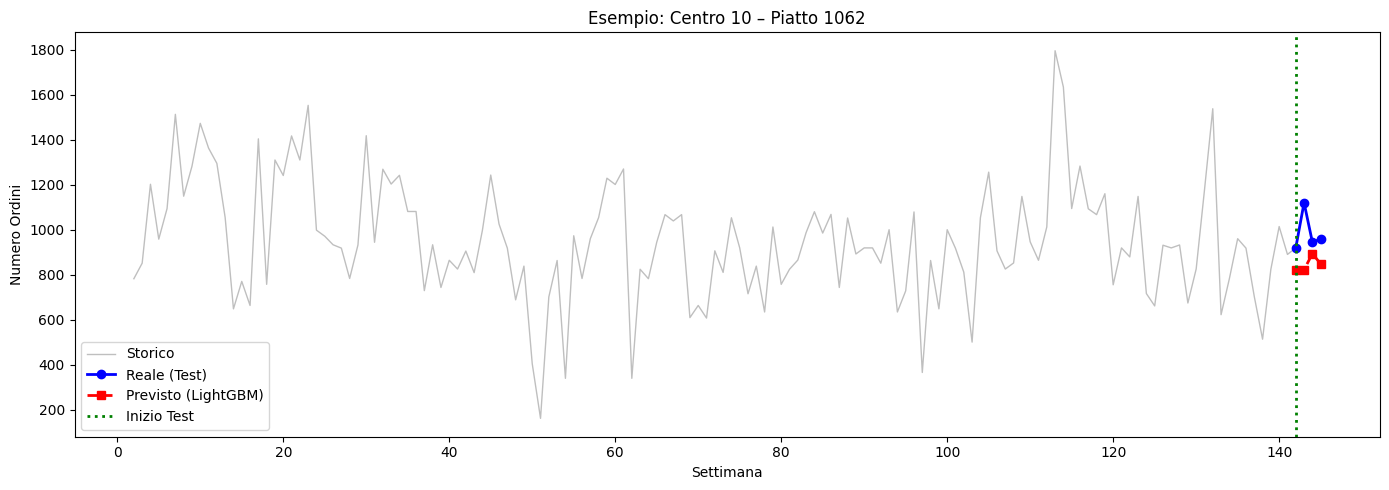

In [10]:
# ============================================================
# CELLA 8: ESEMPIO VISIVO SU UNA SINGOLA SERIE
# ============================================================
# Scegliamo un centro e un piatto e mostriamo la previsione nel tempo

# Prendiamo la combinazione con più dati nel test set
combo = df_test.groupby(['center_id', 'meal_id'], observed=True).size().idxmax()
centro_esempio, piatto_esempio = combo

# Filtriamo tutto il dataset per questa combinazione
serie_completa = df[(df['center_id'] == centro_esempio) & (df['meal_id'] == piatto_esempio)].copy()
serie_test = df_test[(df_test['center_id'] == centro_esempio) & (df_test['meal_id'] == piatto_esempio)].copy()

fig, ax = plt.subplots(figsize=(14, 5))

# Storico completo
ax.plot(serie_completa['week'], serie_completa['num_orders_capped'], 
        color='gray', alpha=0.5, label='Storico', linewidth=1)

# Zoom sul test
idx_test = serie_test.index
previsioni_serie = previsioni_reali[np.isin(np.arange(len(df_test)), 
                                            [list(df_test.index).index(i) for i in idx_test])]

ax.plot(serie_test['week'].values, serie_test['num_orders_capped'].values,
        'b-o', label='Reale (Test)', linewidth=2, markersize=6)
ax.plot(serie_test['week'].values, previsioni_serie,
        'r--s', label='Previsto (LightGBM)', linewidth=2, markersize=6)

ax.axvline(x=SETTIMANA_TEST, color='green', linestyle=':', linewidth=2, label='Inizio Test')
ax.set_xlabel("Settimana")
ax.set_ylabel("Numero Ordini")
ax.set_title(f"Esempio: Centro {centro_esempio} – Piatto {piatto_esempio}")
ax.legend()
plt.tight_layout()
plt.show()

In [13]:
# from sklearn.metrics import mean_absolute_error, mean_squared_error

# # ── STEP 1: calcola il fattore di correzione sul VALIDATION set ──
# # (Non sul test! Il test non si tocca mai durante la calibrazione)
# pred_val_log   = modello_lgb.predict(X_val)
# pred_val_reale = np.expm1(pred_val_log)
# reale_val      = df_val['num_orders_capped'].values

# bias_correction = reale_val.mean() / pred_val_reale.mean()
# print(f"Fattore di correzione calcolato sul validation set: {bias_correction:.4f}")
# print(f"(Significa che il modello sottostimava del {(bias_correction-1)*100:.1f}% in media)\n")

# # ── STEP 2: applica la correzione alle previsioni sul TEST set ──
# pred_test_log         = modello_lgb.predict(X_test)
# pred_test_raw         = np.expm1(pred_test_log)          # senza correzione
# pred_test_corrected   = pred_test_raw * bias_correction  # con correzione

# # ── STEP 3: confronto completo ──
# mae_lgb_raw       = mean_absolute_error(y_test_reale, pred_test_raw)
# mae_lgb_corrected = mean_absolute_error(y_test_reale, pred_test_corrected)
# rmse_lgb_raw      = np.sqrt(mean_squared_error(y_test_reale, pred_test_raw))
# rmse_lgb_corrected= np.sqrt(mean_squared_error(y_test_reale, pred_test_corrected))
# bias_raw          = (pred_test_raw       - y_test_reale.values).mean()
# bias_corrected    = (pred_test_corrected - y_test_reale.values).mean()
# miglioramento_raw       = (mae_baseline - mae_lgb_raw)       / mae_baseline * 100
# miglioramento_corrected = (mae_baseline - mae_lgb_corrected) / mae_baseline * 100

# print("=" * 60)
# print("  CONFRONTO COMPLETO")
# print("=" * 60)
# print(f"  {'':30s}  {'MAE':>8}  {'RMSE':>8}  {'Bias':>8}")
# print(f"  {'-'*56}")
# print(f"  {'Baseline (Seasonal Naive)':30s}  {mae_baseline:>8.2f}  {rmse_baseline:>8.2f}  {'--':>8}")
# print(f"  {'LightGBM (senza correzione)':30s}  {mae_lgb_raw:>8.2f}  {rmse_lgb_raw:>8.2f}  {bias_raw:>+8.2f}")
# print(f"  {'LightGBM (con correzione)':30s}  {mae_lgb_corrected:>8.2f}  {rmse_lgb_corrected:>8.2f}  {bias_corrected:>+8.2f}")
# print("=" * 60)
# print(f"  Miglioramento vs baseline (raw):        {miglioramento_raw:.1f}%")
# print(f"  Miglioramento vs baseline (corretto):   {miglioramento_corrected:.1f}%")
# print("=" * 60)

# # ── STEP 4: salva il fattore di correzione insieme al modello ──
# import joblib, os
# os.makedirs('models', exist_ok=True)
# joblib.dump(modello_lgb, 'models/modello_lgbm.pkl')
# joblib.dump(bias_correction, 'models/bias_correction.pkl')
# print(f"\n✅ Modello salvato in models/modello_lgbm.pkl")
# print(f"✅ Fattore di correzione salvato in models/bias_correction.pkl")

In [14]:
# ============================================================
# CELLA 9: SALVATAGGIO MODELLO E RISULTATI PER LE FASI SUCCESSIVE
# ============================================================

# 1. Salva il modello addestrato (per la Fase 5 - Web App)
joblib.dump(modello_lgb, 'modello_lgbm.pkl')
print("✅ Modello salvato: 'modello_lgbm.pkl'")

# 2. Salva la lista delle features (servirà alla web app per sapere l'ordine delle colonne)
joblib.dump(features, 'features_lista.pkl')
print("✅ Lista features salvata: 'features_lista.pkl'")

# 3. Salva il test set con le previsioni allegate (per la Fase 4 - Business Simulation)
df_test_risultati = df_test.copy()
df_test_risultati['previsione_lgb'] = previsioni_reali
df_test_risultati['previsione_baseline'] = baseline_pred.values

os.makedirs('data/processed', exist_ok=True)
df_test_risultati.to_csv('data/processed/test_con_previsioni.csv', index=False)
print("✅ Test set con previsioni salvato: 'data/processed/test_con_previsioni.csv'")

# 4. Salva le metriche in un dizionario (per il README)
metriche = {
    'mae_baseline': mae_baseline,
    'rmse_baseline': rmse_baseline,
    'mae_lgb': mae_lgb,
    'rmse_lgb': rmse_lgb,
    'miglioramento_mae_%': miglioramento_mae,
    'miglioramento_rmse_%': miglioramento_rmse,
    'n_alberi_ottimale': modello_lgb.best_iteration_,
    'n_features': len(features),
    'n_righe_train': len(X_train),
    'n_righe_test': len(X_test)
}
joblib.dump(metriche, 'metriche_modello.pkl')
print("✅ Metriche salvate: 'metriche_modello.pkl'")

✅ Modello salvato: 'modello_lgbm.pkl'
✅ Lista features salvata: 'features_lista.pkl'
✅ Test set con previsioni salvato: 'data/processed/test_con_previsioni.csv'
✅ Metriche salvate: 'metriche_modello.pkl'
